#데이터 가져오기

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


stock_data = pd.read_csv('./USA.csv')

stock_data.head() #작업내용 확인용 출력

,일자,송금(보내실때),송금(받으실때),현찰(사실때),현찰(파실때),기준환율
0,2023.6.26,1321.6,1296.4,1331.90,1286.10,1302.2
1,2023.6.23,1323.2,1297.8,1333.43,1287.57,1291.4
2,2023.6.22,1311.6,1286.4,1321.73,1276.27,1291.5
3,2023.6.21,1306.0,1281.0,1316.13,1270.87,1282.2
4,2023.6.20,1302.5,1277.5,1312.57,1267.43,1280.7


#데이터 전처리

In [3]:
# save original 'Open' prices for later
original_open = stock_data['기준환율'].values

# separate dates for future plotting
dates = pd.to_datetime(stock_data['일자'])

In [4]:
# variables for training
cols = list(stock_data)[1:5]

# new dataframe with only training data - 5 columns
stock_data = stock_data[cols].astype(float)

정규화

In [5]:
from sklearn.preprocessing import StandardScaler

# normalize the dataset
scaler = StandardScaler()
scaler = scaler.fit(stock_data)
stock_data_scaled = scaler.transform(stock_data)

In [6]:
# split to train data and test data
n_train = int(0.9*stock_data_scaled.shape[0])
train_data_scaled = stock_data_scaled[0: n_train]
train_dates = dates[0: n_train]

test_data_scaled = stock_data_scaled[n_train:]
test_dates = dates[n_train:]

In [7]:
# data reformatting for LSTM
pred_days = 1  # prediction period
seq_len = 14   # sequence length = past days for future prediction.
input_dim = 5  # input_dimension = ['Open', 'High', 'Low', 'Close', 'Volume']

trainX = []
trainY = []
testX = []
testY = []

for i in range(seq_len, n_train-pred_days +1):
    trainX.append(train_data_scaled[i - seq_len:i, 0:train_data_scaled.shape[1]])
    trainY.append(train_data_scaled[i + pred_days - 1:i + pred_days, 0])

for i in range(seq_len, len(test_data_scaled)-pred_days +1):
    testX.append(test_data_scaled[i - seq_len:i, 0:test_data_scaled.shape[1]])
    testY.append(test_data_scaled[i + pred_days - 1:i + pred_days, 0])

trainX, trainY = np.array(trainX), np.array(trainY)
testX, testY = np.array(testX), np.array(testY)

# 모델 학습

In [8]:
model = Sequential()
model.add(LSTM(64, input_shape=(trainX.shape[1], trainX.shape[2]),
               return_sequences=True))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(trainY.shape[1]))

In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 14, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 30,113
Trainable params: 30,113
Non-trainable params: 0
_________________________________________________________________


In [10]:
# specify your learning rate
learning_rate = 0.01
# create an Adam optimizer with the specified learning rate
optimizer = Adam(learning_rate=learning_rate)
# compile your model using the custom optimizer
model.compile(optimizer=optimizer, loss='mse')

# 모델 저장

No weights found, training model from scratch
Epoch 1/30
6/6 [==============================] - 8s 224ms/step - loss: 0.4205 - val_loss: 0.1674
Epoch 2/30
6/6 [==============================] - 0s 27ms/step - loss: 0.1454 - val_loss: 0.0481
Epoch 3/30
6/6 [==============================] - 0s 26ms/step - loss: 0.1242 - val_loss: 0.1333
Epoch 4/30
6/6 [==============================] - 0s 29ms/step - loss: 0.0818 - val_loss: 0.0469
Epoch 5/30
6/6 [==============================] - 0s 25ms/step - loss: 0.0595 - val_loss: 0.0455
Epoch 6/30
6/6 [==============================] - 0s 27ms/step - loss: 0.0523 - val_loss: 0.0351
Epoch 7/30
6/6 [==============================] - 0s 26ms/step - loss: 0.0466 - val_loss: 0.0380
Epoch 8/30
6/6 [==============================] - 0s 27ms/step - loss: 0.0480 - val_loss: 0.0561
Epoch 9/30
6/6 [==============================] - 0s 27ms/step - loss: 0.0419 - val_loss: 0.0324
Epoch 10/30
6/6 [==============================] - 0s 33ms/step - loss: 0.0391 -

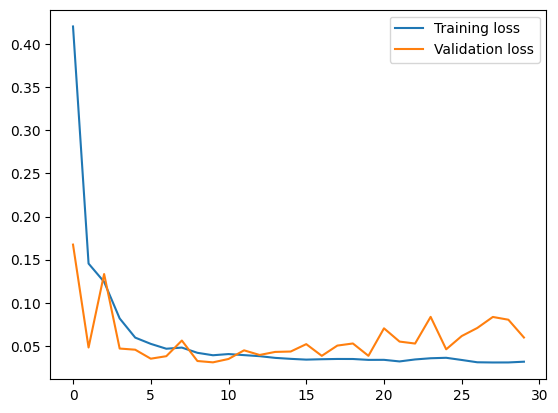

In [11]:
import os

# 디렉토리 생성
save_dir = './save_weights'
os.makedirs(save_dir, exist_ok=True)

# 가중치 파일 경로
weights_file = os.path.join(save_dir, 'lstm_weights.h5')

try:
    model.load_weights(weights_file)
    print("Loaded model weights from disk")
except:
    print("No weights found, training model from scratch")
    # Fit the model
    history = model.fit(trainX, trainY, epochs=30, batch_size=32,
                    validation_split=0.1, verbose=1)

    model.save_weights(weights_file)

    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.legend()
    plt.show()


# 전체코드

1/1 [==============================] - 1s 821ms/step
(11, 1) (11, 1)
(11,)
(11,)


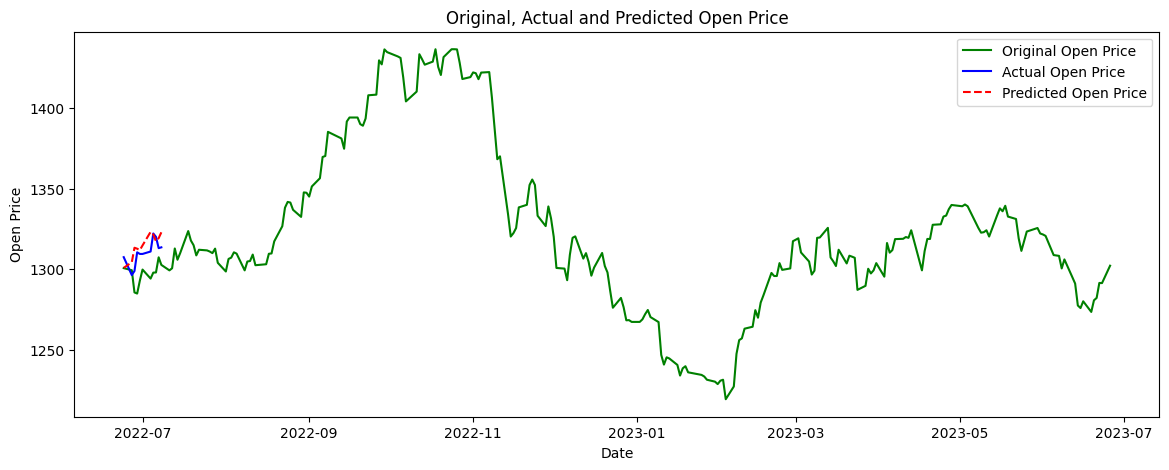

In [ ]:
# prediction
prediction = model.predict(testX)
print(prediction.shape, testY.shape)

# generate array filled with means for prediction
mean_values_pred = np.repeat(scaler.mean_[np.newaxis, :], prediction.shape[0], axis=0)

# substitute predictions into the first column
mean_values_pred[:, 0] = np.squeeze(prediction)

# inverse transform
y_pred = scaler.inverse_transform(mean_values_pred)[:,0]
print(y_pred.shape)

# generate array filled with means for testY
mean_values_testY = np.repeat(scaler.mean_[np.newaxis, :], testY.shape[0], axis=0)

# substitute testY into the first column
mean_values_testY[:, 0] = np.squeeze(testY)

# inverse transform
testY_original = scaler.inverse_transform(mean_values_testY)[:,0]
print(testY_original.shape)

# plotting
plt.figure(figsize=(14, 5))

# plot original 'Open' prices
plt.plot(dates, original_open, color='green', label='Original Open Price')

# plot actual vs predicted
plt.plot(test_dates[seq_len:], testY_original, color='blue', label='Actual Open Price')
plt.plot(test_dates[seq_len:], y_pred, color='red', linestyle='--', label='Predicted Open Price')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Original, Actual and Predicted Open Price')
plt.legend()
plt.show()

In [ ]:
testY_original

array([1313.6, 1313.1, 1320.1, 1322.2, 1311. , 1309.5, 1309.5, 1310.5,
       1298.9, 1296.4, 1307.5])

In [ ]:
y_pred

array([1322.93087322, 1319.29456904, 1317.40786667, 1321.58822393,
       1323.20680241, 1314.79150902, 1311.86961106, 1312.75479784,
       1313.3419187 , 1304.30344534, 1300.86297987])

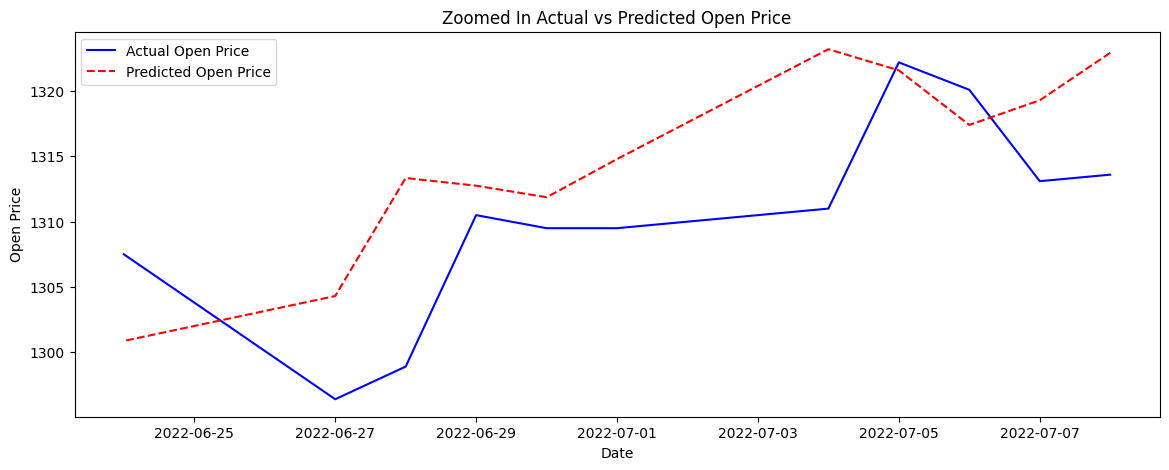

In [ ]:
# Calculate the start and end indices for the zoomed plot
zoom_start = len(test_dates) - 11
zoom_end = len(test_dates)

# Create the zoomed plot
plt.figure(figsize=(14, 5))

plt.plot(test_dates[zoom_start:zoom_end],
         testY_original,
         color='blue',
         label='Actual Open Price')

plt.plot(test_dates[zoom_start:zoom_end],
         y_pred,
         color='red',
         linestyle='--',
         label='Predicted Open Price')

plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Zoomed In Actual vs Predicted Open Price')
plt.legend()
plt.show()


In [1]:
# import libraries
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# read the csv file
stock_data = pd.read_csv('./USA.csv')
stock_data.drop(['Adj Close'], axis=1, inplace=True) # delete adjusted close

# save original 'Open' prices for later
original_open = stock_data['Open'].values

# separate dates for future plotting
dates = pd.to_datetime(stock_data['Date'])

# variables for training
cols = list(stock_data)[1:6]

# new dataframe with only training data - 5 columns
stock_data = stock_data[cols].astype(float)

# normalize the dataset
scaler = StandardScaler()
scaler = scaler.fit(stock_data)
stock_data_scaled = scaler.transform(stock_data)

# split to train data and test data
n_train = int(0.9*stock_data_scaled.shape[0])
train_data_scaled = stock_data_scaled[0: n_train]
train_dates = dates[0: n_train]

test_data_scaled = stock_data_scaled[n_train:]
test_dates = dates[n_train:]
# print(test_dates.head(5))

# data reformatting for LSTM
pred_days = 1  # prediction period
seq_len = 14   # sequence length = past days for future prediction.
input_dim = 5  # input_dimension = ['Open', 'High', 'Low', 'Close', 'Volume']

trainX = []
trainY = []
testX = []
testY = []

for i in range(seq_len, n_train-pred_days +1):
    trainX.append(train_data_scaled[i - seq_len:i, 0:train_data_scaled.shape[1]])
    trainY.append(train_data_scaled[i + pred_days - 1:i + pred_days, 0])

for i in range(seq_len, len(test_data_scaled)-pred_days +1):
    testX.append(test_data_scaled[i - seq_len:i, 0:test_data_scaled.shape[1]])
    testY.append(test_data_scaled[i + pred_days - 1:i + pred_days, 0])

trainX, trainY = np.array(trainX), np.array(trainY)
testX, testY = np.array(testX), np.array(testY)

# print(trainX.shape, trainY.shape)
# print(testX.shape, testY.shape)

# LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(trainX.shape[1], trainX.shape[2]), # (seq length, input dimension)
               return_sequences=True))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(trainY.shape[1]))

model.summary()

# specify your learning rate
learning_rate = 0.01
# create an Adam optimizer with the specified learning rate
optimizer = Adam(learning_rate=learning_rate)
# compile your model using the custom optimizer
model.compile(optimizer=optimizer, loss='mse')

# Try to load weights
try:
    model.load_weights('./save_weights/lstm_weights.h5')
    print("Loaded model weights from disk")
except:
    print("No weights found, training model from scratch")
    # Fit the model
    history = model.fit(trainX, trainY, epochs=30, batch_size=32,
                    validation_split=0.1, verbose=1)
    # Save model weights after training
    model.save_weights('./save_weights/lstm_weights.h5')

    plt.plot(history.history['loss'], label='Training loss')
    plt.plot(history.history['val_loss'], label='Validation loss')
    plt.legend()
    plt.show()


# prediction
prediction = model.predict(testX)
print(prediction.shape, testY.shape)

# generate array filled with means for prediction
mean_values_pred = np.repeat(scaler.mean_[np.newaxis, :], prediction.shape[0], axis=0)

# substitute predictions into the first column
mean_values_pred[:, 0] = np.squeeze(prediction)

# inverse transform
y_pred = scaler.inverse_transform(mean_values_pred)[:,0]
print(y_pred.shape)

# generate array filled with means for testY
mean_values_testY = np.repeat(scaler.mean_[np.newaxis, :], testY.shape[0], axis=0)

# substitute testY into the first column
mean_values_testY[:, 0] = np.squeeze(testY)

# inverse transform
testY_original = scaler.inverse_transform(mean_values_testY)[:,0]
print(testY_original.shape)

# plotting
plt.figure(figsize=(14, 5))

# plot original 'Open' prices
plt.plot(dates, original_open, color='green', label='Original Open Price')

# plot actual vs predicted
plt.plot(test_dates[seq_len:], testY_original, color='blue', label='Actual Open Price')
plt.plot(test_dates[seq_len:], y_pred, color='red', linestyle='--', label='Predicted Open Price')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Original, Actual and Predicted Open Price')
plt.legend()
plt.show()

# Calculate the start and end indices for the zoomed plot
zoom_start = len(test_dates) - 50
zoom_end = len(test_dates)

# Create the zoomed plot
plt.figure(figsize=(14, 5))

# Adjust the start index for the testY_original and y_pred arrays
adjusted_start = zoom_start - seq_len

plt.plot(test_dates[zoom_start:zoom_end],
         testY_original[adjusted_start:zoom_end - zoom_start + adjusted_start],
         color='blue',
         label='Actual Open Price')

plt.plot(test_dates[zoom_start:zoom_end],
         y_pred[adjusted_start:zoom_end - zoom_start + adjusted_start ],
         color='red',
         linestyle='--',
         label='Predicted Open Price')

plt.xlabel('Date')
plt.ylabel('Open Price')
plt.title('Zoomed In Actual vs Predicted Open Price')
plt.legend()
plt.show()

KeyError: ignored

https://pasus.tistory.com/266 참고